## 그래프 연결(컴파일) 및 실행

<br>

### 그래프 정의
- `StateGraph` 객체 생성 : 상태 기반의 계산 그래프를 정의

<br>

```python
graph = StateGraph(MyState)
```

<br>

### 그래프 컴파일
- `compile()` 메서드는 정의된 그래프를 실행 가능한 형태로 변환
  - 이 과정에서 그래프의 구조가 검증되고, 최적화
  - 컴파일된 그래프는 `app`변수에 저장되며, 실행할 준비가 된 상태

<br>

```python
app = graph.compile()
```

<br>

### 그래프 실행
- `invoke()`메서드는 컴파일된 그래프를 실행
  - 랭체인에서 사용하는 문법 구조를 그대로 준용
- 인자로 전달된 초기 상태는, 상태 클래스의 구조와 일치해야 함
- 그래프는 초기 상태부터 시작하여 정의된 노드들을 순차적으로 실행

<br>

```python
result = app.invoke({"counter": 0})
```

<br>

### 결과 출력
- 그래프 실행의 결과를 출력

<br>

#### 주요 과정
1. **상태 기반 계산** : LangGraph는 상태를 중심으로 동작. 각 노드는 현재 상태를 입력으로 받아 새로운 상태를 출력
2. **그래프 구조** : 노드와 엣지로 구성된 그래프 구조를 통해 복잡한 워크플로우를 모델링
3. **컴파일 과정** : 컴파일은 정의된 그래프를 효율적으로 실행할 수 있는 형태로 변환. 이 과정에서 그래프의 일관성 검사도 이루어 짐
4. **실행 흐름** : 그래프 실행은 초기 상태에서 시작하여 정의된 노드들을 순차적으로 처리하며, 각 노드는 상태를 업데이트 함

<br>


### 그래프 구성 요소 연결
- 그래프 구성 요소 연결은 LangGraph 애플리케이션의 아키텍처 품질을 결정하는 핵심 과정
  - 그래프 구성은 단순히 노드와 엣지를 연결하는 것을 넘어서, **비즈니스 로직의 흐름을 명확하게 표현하고 예외 상황을 적절하게 처리하며 시스템의 안정성과 확장성을 보장하는 종합적인 설계 과정**
- **그래프 구성의 핵심 원칙은 책임 분리(Separation of Concerns)** 에 있습니다. 각 노드는 명확하고 단일한 책임을 가져야 하며, 상태의 특정 측면만을 업데이트

<br>

#### 그래프 구성 예시

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import TypedDict, Literal, Annotated, Optional
import operator
from datetime import datetime
from visualize_graph import visualize_graph

- 상태 정의

In [2]:
class WorkflowState(TypedDict):
    input_data: str
    processing_stage: str
    results: Annotated[list, operator.add]
    error: Optional[str]
    metadata: dict

- 노드 함수 정의

In [3]:
def validate_input(state: WorkflowState) -> dict:
    """입력 검증 노드"""
    input_data = state["input_data"]

    if not input_data:
        return {
            "error": "입력 데이터가 비어있습니다",
            "processing_stage": "validation_failed"
        }

    if len(input_data) > 1000:
        return {
            "error": "입력 데이터가 너무 깁니다",
            "processing_stage": "validation_failed"
        }

    return {
        "processing_stage": "validated",
        "results": ["입력 검증 완료"]
    }

In [4]:
def process_data(state: WorkflowState) -> dict:
    """데이터 처리 노드"""
    # 실제 처리 로직
    processed = state["input_data"].upper()

    return {
        "processing_stage": "processed",
        "results": [f"처리 결과: {processed}"],
        "metadata": {
            **state.get("metadata", {}),
            "processed_at": datetime.now().isoformat()
        }
    }

In [5]:
def generate_output(state: WorkflowState) -> dict:
    """출력 생성 노드"""
    final_output = "\n".join(state["results"])

    return {
        "processing_stage": "completed",
        "results": [f"최종 출력: {final_output}"],
        "metadata": {
            **state["metadata"],
            "completed_at": datetime.now().isoformat()
        }
    }

In [6]:
def handle_error(state: WorkflowState) -> dict:
    """에러 처리 노드"""
    return {
        "processing_stage": "error_handled",
        "results": [f"에러 처리: {state['error']}"]
    }

- 라우팅 함수

In [7]:
def route_after_validation(state: WorkflowState) -> str:
    """검증 후 라우팅"""
    if state.get("error"):
        return "error"
    return "process"

- 그래프 구성

In [8]:
workflow = StateGraph(WorkflowState)

# 노드 추가
workflow.add_node("validate", validate_input)
workflow.add_node("process", process_data)
workflow.add_node("output", generate_output)
workflow.add_node("error_handler", handle_error)

# 엣지 추가
workflow.add_edge(START, "validate")
workflow.add_conditional_edges(
    "validate",
    route_after_validation,
    {
        "process": "process",
        "error": "error_handler"
    }
)
workflow.add_edge("process", "output")
workflow.add_edge("output", END)
workflow.add_edge("error_handler", END)

# 그래프 컴파일
app = workflow.compile()

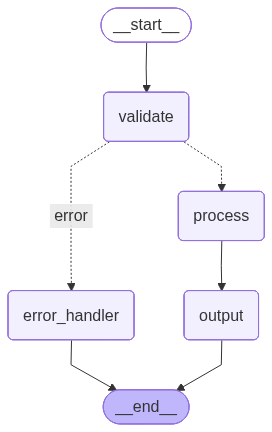

In [9]:
visualize_graph(app)

<br>

### 그래프 실행 방법 (`invoke`, `stream`, `async`)

<table>
<thead>
<tr>
<th>메서드</th>
<th>설명</th>
<th>용도</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>invoke()</code></td>
<td>동기 실행, 최종 결과 반환</td>
<td>배치 처리, 테스트</td>
</tr>
<tr>
<td><code>stream()</code></td>
<td>동기 스트리밍, 중간 결과 반환</td>
<td>실시간 UI</td>
</tr>
<tr>
<td><code>ainvoke()</code></td>
<td>비동기 실행</td>
<td>고동시성 서버</td>
</tr>
<tr>
<td><code>astream()</code></td>
<td>비동기 스트리밍</td>
<td>비동기 실시간 UI</td>
</tr>
</tbody>
</table>

<br>

### 동기 실행 : `invoke`
- 전체 그래프 실행이 완료될 떄까지 대기

<br>

```python
result = app.invoke({"counter": 0, "messages": []})
print(f"최종 상태: {result}")
```

<br>

#### 설정 매개변수

<br>

```python
config = {
    "configurable": {
        "thread_id": "user_123"   # 세션 식별자
    }
}
result = app.invoke({"counter": 0}, config=config)
```

<br>

#### 재귀 제한 설정
- 무한 루프 방지

<br>

```python
result = app.invoke(
    {"counter": 0},
    {"recursion_limit": 10}  # 최대 10회 슈퍼스텝
)
```

<br>

### 스트리밍 실행 : `stream`
- 각 노드의 실행 결과를 실시간으로 받아볼 수 있음

<br>

```python
for state in app.stream(
    {"counter": 0},
    stream_mode="values"
):
    print(f"현재 상태: {state}")
```

<br>

- **스트림 종류**

<table>
<thead>
<tr>
<th>모드</th>
<th>설명</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>values</code></td>
<td>각 단계 후 전체 상태</td>
</tr>
<tr>
<td><code>updates</code></td>
<td>변경된 부분만</td>
</tr>
<tr>
<td><code>messages</code></td>
<td>LLM 토큰 단위 스트리밍</td>
</tr>
<tr>
<td><code>custom</code></td>
<td>사용자 정의 데이터</td>
</tr>
<tr>
<td><code>debug</code></td>
<td>상세 실행 정보</td>
</tr>
</tbody>
</table>

<br>

### 비동기 실행

<br>

#### `ainvoke`

<br>

```python
async def process():
    result = await app.ainvoke({"counter": 0})
    return result
```

<br>

#### `astream`

<br>

```python
async def stream_process():
    async for chunk in app.astream(
        {"counter": 0},
        stream_mode="values"
    ):
        print(chunk)
```

<br>

#### `병렬 실행`

<br>

```python
import asyncio

results = await asyncio.gather(
    app.ainvoke({"counter": 0}),
    app.ainvoke({"counter": 10}),
    app.ainvoke({"counter": 20})
)
```

<br>

### 실행 방법의 선택

<br>

#### invoke 권장
- 배치 처리 시스템
- 단순 API 요청-응답
- 테스트 및 디버깅

<br>

#### stream 권장
- 실시간 사용자 피드백
- 장시간 작업 진행 표시
- 챗봇 응답 스트리밍

<br>

#### async 권장
- 고동시성 서버
- I/O 집약적 워크플로우
- 마이크로서비스 환경

<br>

<hr>